# Fraud Detection in Financial Transactions using NetworkX

This notebook demonstrates a complete end-to-end fraud detection application using NetworkX graph analysis.

**Application Goal:** Detect fraudulent transactions and fraud rings in financial networks.

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

sns.set_style('whitegrid')
np.random.seed(42)

## 1. Data Loading

In [6]:
df = pd.read_csv("dataset.csv")

# --- Print summary ---
print("\nDataset Summary:")
print(f"  Total Transactions: {len(df):,}")
print(f"  Fraudulent: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)")
fraud_users = df['isFraud'].sum()
n_users = df.shape[0]
print(f"  Fraudulent Users: {(fraud_users)} ({(fraud_users)/n_users:.1%})")
print(f"  Transaction Types: {df['type'].unique().tolist()}")

df.head()



Dataset Summary:
  Total Transactions: 5,000
  Fraudulent: 789 (15.78%)
  Fraudulent Users: 789 (15.8%)
  Transaction Types: ['PAYMENT', 'TRANSFER', 'CASH_OUT']


,step,type,amount,nameOrig,nameDest,isFraud
0,0,PAYMENT,180.903249,C00131,C00128,0
1,0,TRANSFER,22900.903450,C00156,C00055,1
2,0,TRANSFER,85.332576,C00184,C00057,0
3,0,TRANSFER,3298.568240,C00112,C00150,1
4,0,PAYMENT,3364.690820,C00054,C00142,0


## 2. Exploratory Data Analysis

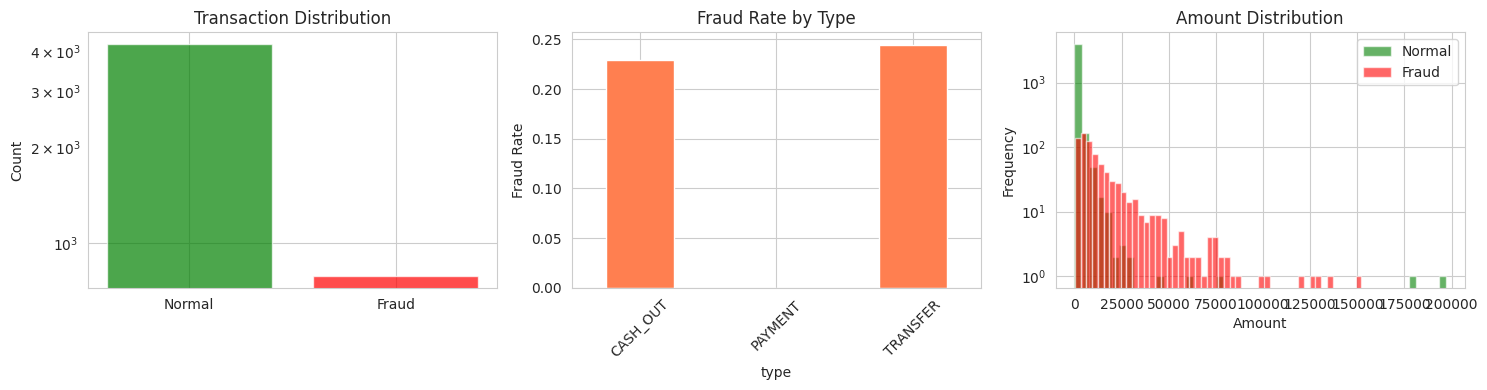

In [7]:
# Fraud distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fraud counts
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Normal', 'Fraud'], fraud_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Distribution')
axes[0].set_yscale('log')

# Fraud by type
fraud_by_type = df.groupby('type')['isFraud'].mean()
fraud_by_type.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate by Type')
axes[1].tick_params(axis='x', rotation=45)

# Amount distribution
axes[2].hist(df[df['isFraud']==0]['amount'], bins=50, alpha=0.6, label='Normal', color='green')
axes[2].hist(df[df['isFraud']==1]['amount'], bins=50, alpha=0.6, label='Fraud', color='red')
axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Amount Distribution')
axes[2].legend()
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 3. Create Transaction Network

In [8]:
# Use wrapper to create graph
G = create_transaction_graph(df, directed=True)

print(f"Transaction Network:")
print(f"  Nodes: {G.number_of_nodes():,}")
print(f"  Edges: {G.number_of_edges():,}")

2025-12-06 20:17:07.751 | INFO     | utils:create_transaction_graph:52 - Created graph: 200 nodes, 4097 edges


Transaction Network:
  Nodes: 200
  Edges: 4,097


## 4. Analyze Network Structure

In [9]:
# Get comprehensive network statistics
stats = analyze_network_structure(G)

print("\nNetwork Statistics:")
print("="*50)
for key, value in stats.items():
    print(f"  {key}: {value}")
print("="*50)

2025-12-06 20:17:08.522 | INFO     | utils:analyze_network_structure:176 - Network structure analyzed



Network Statistics:
  nodes: 200
  edges: 4097
  density: 0.10293969849246232
  avg_degree: 40.97
  is_connected: True
  num_components: 1


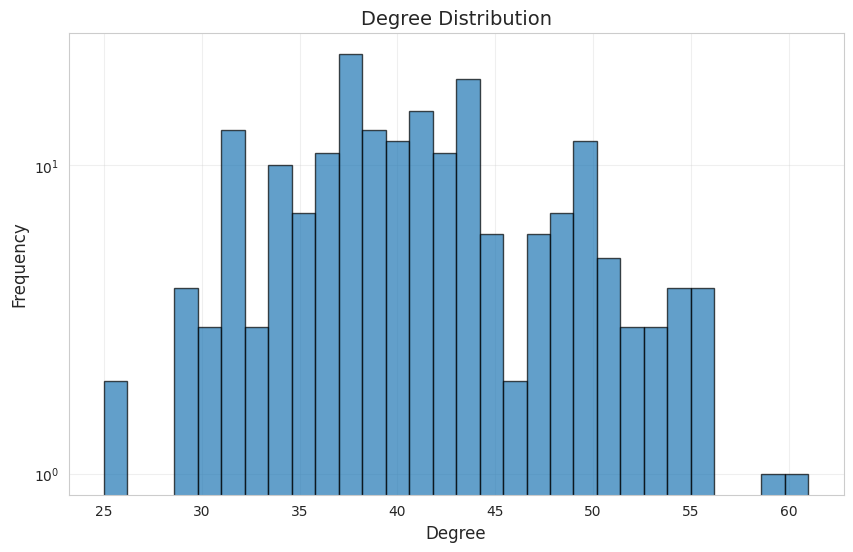

In [10]:
# Degree distribution
plot_degree_distribution(G)

## 5. Compute Centrality Measures

In [11]:
# Degree centrality
degree_cent = compute_degree_centrality(G)
top_degree = get_top_central_nodes(G, metric='degree', top_n=10)

print("Top 10 Nodes by Degree Centrality:")
for node, score in top_degree:
    print(f"  {node}: {score:.4f}")

2025-12-06 20:17:09.241 | INFO     | utils:compute_degree_centrality:70 - Degree centrality computed


Top 10 Nodes by Degree Centrality:
  C00108: 0.3065
  C00009: 0.2965
  C00034: 0.2814
  C00170: 0.2764
  C00194: 0.2764
  C00186: 0.2764
  C00155: 0.2714
  C00115: 0.2714
  C00166: 0.2714
  C00094: 0.2714


In [12]:
# Betweenness centrality
betweenness = compute_betweenness_centrality(G)
top_betweenness = get_top_central_nodes(G, metric='betweenness', top_n=10)

print("\nTop 10 Nodes by Betweenness Centrality:")
for node, score in top_betweenness:
    print(f"  {node}: {score:.4f}")

2025-12-06 20:17:09.541 | INFO     | utils:compute_betweenness_centrality:84 - Betweenness centrality computed



Top 10 Nodes by Betweenness Centrality:
  C00108: 0.0102
  C00034: 0.0098
  C00038: 0.0094
  C00186: 0.0094
  C00009: 0.0094
  C00115: 0.0093
  C00175: 0.0087
  C00155: 0.0085
  C00170: 0.0084
  C00032: 0.0084


In [13]:
# PageRank
pagerank = compute_pagerank(G)
top_pagerank = get_top_central_nodes(G, metric='pagerank', top_n=10)

print("\nTop 10 Nodes by PageRank:")
for node, score in top_pagerank:
    print(f"  {node}: {score:.4f}")

ModuleNotFoundError: No module named 'scipy'

In [ ]:
# Compare centrality measures
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scores = list(degree_cent.values())
axes[0].hist(scores, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Degree Centrality')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Centrality Distribution')

scores = list(betweenness.values())
axes[1].hist(scores, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Betweenness Centrality Distribution')

scores = list(pagerank.values())
axes[2].hist(scores, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_xlabel('PageRank')
axes[2].set_ylabel('Frequency')
axes[2].set_title('PageRank Distribution')

plt.tight_layout()
plt.show()

## 6. Fraud Pattern Detection

In [14]:
# Find nodes involved in fraud
fraud_nodes = find_fraud_nodes(G)

print(f"Fraud Detection Results:")
print(f"  Nodes involved in fraud: {len(fraud_nodes)}")
print(f"  Percentage of users: {len(fraud_nodes)/G.number_of_nodes()*100:.2f}%")

2025-12-06 20:17:10.428 | INFO     | utils:find_fraud_nodes:199 - Found 35 nodes involved in fraud


Fraud Detection Results:
  Nodes involved in fraud: 35
  Percentage of users: 17.50%


In [15]:
# Find hub accounts
hubs = find_hub_accounts(G, threshold_percentile=90)

print(f"\nHub Accounts (top 10%):")
print(f"  Found {len(hubs)} hub accounts")
print("\nTop 5 Hubs:")
for node, degree in hubs[:5]:
    is_fraudster = "⚠️ FRAUD" if node in fraud_nodes else "✓ Clean"
    print(f"  {node}: {degree} connections [{is_fraudster}]")

2025-12-06 20:17:10.898 | INFO     | utils:find_hub_accounts:217 - Found 16 hub accounts (>90th percentile)



Hub Accounts (top 10%):
  Found 16 hub accounts

Top 5 Hubs:
  C00055: 52 connections [⚠️ FRAUD]
  C00170: 55 connections [⚠️ FRAUD]
  C00108: 61 connections [⚠️ FRAUD]
  C00144: 52 connections [✓ Clean]
  C00155: 54 connections [⚠️ FRAUD]


In [16]:
# Find intermediary accounts
intermediaries = find_intermediary_accounts(G, threshold_percentile=90)

print(f"\nIntermediary Accounts (top 10% by betweenness):")
print(f"  Found {len(intermediaries)} intermediaries")
print("\nTop 5 Intermediaries:")
for node, score in intermediaries[:5]:
    is_fraudster = "⚠️ FRAUD" if node in fraud_nodes else "✓ Clean"
    print(f"  {node}: {score:.4f} [{is_fraudster}]")

2025-12-06 20:17:11.307 | INFO     | utils:find_intermediary_accounts:236 - Found 20 intermediary accounts



Intermediary Accounts (top 10% by betweenness):
  Found 20 intermediaries

Top 5 Intermediaries:
  C00170: 0.0084 [⚠️ FRAUD]
  C00108: 0.0102 [⚠️ FRAUD]
  C00067: 0.0083 [✓ Clean]
  C00155: 0.0085 [⚠️ FRAUD]
  C00098: 0.0076 [⚠️ FRAUD]


### Key Finding
Many hub and intermediary accounts are involved in fraud!

## 7. Detect Fraud Rings

In [17]:
# Detect fraud rings
fraud_rings = detect_fraud_rings(G, min_size=3)

print(f"Fraud Ring Detection:")
print(f"  Found {len(fraud_rings)} suspicious communities")

print("\nTop 3 Suspicious Communities (if any):")
for i, ring in enumerate(fraud_rings[:3], 1):
    print(f"\n  Community {i}:")
    print(f"    Size: {ring['size']} members")
    print(f"    Density: {ring['density']:.3f}")
    print(f"    Has Fraud: {ring['has_fraud']}")
    print(f"    5 Members: {list(ring['nodes'])[:5]}")

2025-12-06 20:17:12.436 | INFO     | utils:detect_fraud_rings:274 - Found 1 suspicious communities


Fraud Ring Detection:
  Found 1 suspicious communities

Top 3 Suspicious Communities (if any):

  Community 1:
    Size: 200 members
    Density: 0.103
    Has Fraud: True
    5 Members: ['C00022', 'C00166', 'C00152', 'C00012', 'C00175']


In [18]:
# # Visualize largest fraud ring
# if len(fraud_rings) > 0:
#     largest_ring = max(fraud_rings, key=lambda x: x['size'])
#     print(f"\nVisualizing largest fraud ring ({largest_ring['size']} members)...")
#     visualize_subgraph(G, list(largest_ring['nodes']), title="Detected Fraud Ring")

## 8. Fraud Risk Scoring

In [19]:
# Rank nodes by fraud risk
risky_accounts = rank_nodes_by_fraud_risk(G, top_n=20)

print("Top 20 Risky Accounts:")
print("="*60)
for i, (node, score) in enumerate(risky_accounts, 1):
    degree = G.degree(node)
    actual_fraud = "✓ TRUE FRAUD" if node in fraud_nodes else "✗ POSSIBLE LINKAGE WITH FRAUD MEMBERS"
    print(f"{i:2d}. {node}: Risk={score:.3f}, Degree={degree:2d} [{actual_fraud}]")
print("="*60)

2025-12-06 20:17:13.442 | INFO     | utils:rank_nodes_by_fraud_risk:322 - Ranked top 20 nodes by fraud risk


Top 20 Risky Accounts:
 1. C00150: Risk=0.197, Degree=51 [✓ TRUE FRAUD]
 2. C00108: Risk=0.162, Degree=61 [✓ TRUE FRAUD]
 3. C00009: Risk=0.159, Degree=59 [✓ TRUE FRAUD]
 4. C00170: Risk=0.154, Degree=55 [✓ TRUE FRAUD]
 5. C00194: Risk=0.154, Degree=55 [✓ TRUE FRAUD]
 6. C00155: Risk=0.153, Degree=54 [✓ TRUE FRAUD]
 7. C00098: Risk=0.152, Degree=53 [✓ TRUE FRAUD]
 8. C00055: Risk=0.151, Degree=52 [✓ TRUE FRAUD]
 9. C00027: Risk=0.150, Degree=51 [✓ TRUE FRAUD]
10. C00047: Risk=0.150, Degree=51 [✓ TRUE FRAUD]
11. C00112: Risk=0.149, Degree=50 [✓ TRUE FRAUD]
12. C00193: Risk=0.149, Degree=50 [✓ TRUE FRAUD]
13. C00133: Risk=0.147, Degree=49 [✓ TRUE FRAUD]
14. C00026: Risk=0.146, Degree=47 [✓ TRUE FRAUD]
15. C00002: Risk=0.146, Degree=47 [✓ TRUE FRAUD]
16. C00021: Risk=0.145, Degree=46 [✓ TRUE FRAUD]
17. C00053: Risk=0.144, Degree=45 [✓ TRUE FRAUD]
18. C00173: Risk=0.144, Degree=45 [✓ TRUE FRAUD]
19. C00109: Risk=0.143, Degree=44 [✓ TRUE FRAUD]
20. C00156: Risk=0.142, Degree=43 [✓ TRUE FRAU

In [20]:
# Calculate detection accuracy
risky_set = set(node for node, _ in risky_accounts)
true_positives = len(risky_set & fraud_nodes)
false_positives = len(risky_set - fraud_nodes)
false_negatives = len(fraud_nodes - risky_set)

precision = true_positives / len(risky_set) if len(risky_set) > 0 else 0
recall = true_positives / len(fraud_nodes) if len(fraud_nodes) > 0 else 0

print(f"\nDetection Performance:")
print(f"  True Positives: {true_positives}")
print(f"  False Positives: {false_positives}")
print(f"  False Negatives: {false_negatives}")
print(f"  Precision: {precision:.2%}")
print(f"  Recall: {recall:.2%}")


Detection Performance:
  True Positives: 20
  False Positives: 0
  False Negatives: 15
  Precision: 100.00%
  Recall: 57.14%


## 9. Visualize Fraud Network

In [ ]:
# Visualize full network
print("Visualizing transaction network...")
visualize_network(G, highlight_fraud=True, figsize=(14, 10), layout='spring')

Visualizing transaction network...


In [ ]:
# Visualize fraud subnetwork
fraud_subgraph = G.subgraph(fraud_nodes)
print(f"\nFraud Subnetwork:")
print(f"  Nodes: {fraud_subgraph.number_of_nodes()}")
print(f"  Edges: {fraud_subgraph.number_of_edges()}")
print(f"  Density: {nx.density(fraud_subgraph):.3f}")

visualize_network(fraud_subgraph, highlight_fraud=True, figsize=(12, 8))

## 10. Compare Fraud vs Normal Networks

In [ ]:
# Compare densities
normal_nodes = set(G.nodes()) - fraud_nodes
normal_sample = list(normal_nodes)[:min(50, len(normal_nodes))]
normal_subgraph = G.subgraph(normal_sample)

fraud_density = nx.density(fraud_subgraph)
normal_density = nx.density(normal_subgraph)

fraud_avg_degree = sum(dict(fraud_subgraph.degree()).values()) / fraud_subgraph.number_of_nodes() if fraud_subgraph.number_of_nodes() > 0 else 0
normal_avg_degree = sum(dict(normal_subgraph.degree()).values()) / normal_subgraph.number_of_nodes() if normal_subgraph.number_of_nodes() > 0 else 0

print("Fraud Network vs Normal Network:")
print("="*60)
print(f"Fraud Network:")
print(f"  Density: {fraud_density:.4f}")
print(f"  Avg Degree: {fraud_avg_degree:.2f}")
print(f"\nNormal Network:")
print(f"  Density: {normal_density:.4f}")
print(f"  Avg Degree: {normal_avg_degree:.2f}")
print("="*60)
if fraud_density > 0 and normal_density > 0:
    print(f"\n→ Fraud networks are {fraud_density/normal_density:.1f}x more dense!")

In [ ]:
# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fraud network
plt.sca(axes[0])
pos1 = nx.spring_layout(fraud_subgraph, seed=42)
nx.draw_networkx_nodes(fraud_subgraph, pos1, node_color='red', node_size=200, alpha=0.7, ax=axes[0])
nx.draw_networkx_edges(fraud_subgraph, pos1, edge_color='darkred', alpha=0.5, arrows=True, ax=axes[0])
axes[0].set_title(f'Fraud Network (Density={fraud_density:.3f})', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Normal network
plt.sca(axes[1])
pos2 = nx.spring_layout(normal_subgraph, seed=42)
nx.draw_networkx_nodes(normal_subgraph, pos2, node_color='lightblue', node_size=200, alpha=0.7, ax=axes[1])
nx.draw_networkx_edges(normal_subgraph, pos2, edge_color='gray', alpha=0.3, arrows=True, ax=axes[1])
axes[1].set_title(f'Normal Network (Density={normal_density:.3f})', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Summary

In [ ]:
print("\n" + "="*70)
print("FRAUD DETECTION APPLICATION SUMMARY")
print("="*70)
print(f"\n1. DATASET")
print(f"   - Total Transactions: {len(df):,}")
print(f"   - Fraudulent: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)")

print(f"\n2. NETWORK ANALYSIS")
print(f"   - Network Nodes: {G.number_of_nodes():,}")
print(f"   - Network Edges: {G.number_of_edges():,}")
print(f"   - Network Density: {stats['density']:.4f}")
print(f"   - Average Degree: {stats['avg_degree']:.2f}")

print(f"\n3. FRAUD DETECTION")
print(f"   - Fraud-involved Users: {len(fraud_nodes)}")
print(f"   - Suspicious Hubs: {len(hubs)}")
print(f"   - Suspicious Intermediaries: {len(intermediaries)}")
print(f"   - Detected Fraud Rings: {len(fraud_rings)}")

print(f"\n4. DETECTION PERFORMANCE")
print(f"   - Precision: {precision:.2%}")
print(f"   - Recall: {recall:.2%}")

print(f"\n5. KEY INSIGHTS")
if fraud_density > 0 and normal_density > 0:
    print(f"   - Fraud networks are {fraud_density/normal_density:.1f}x more dense than normal")
print(f"   - Hub accounts often involved in fraud distribution")
print(f"   - Intermediaries used to layer transactions")
print(f"   - Fraud rings form isolated, tight-knit communities")

print("\n" + "="*70)

## Conclusion

This application demonstrated:

1. **Graph Construction**: Converting transaction data into NetworkX graphs
2. **Centrality Analysis**: Computing degree, betweenness, and PageRank
3. **Fraud Detection**: Identifying suspicious hubs, intermediaries, and rings
4. **Risk Scoring**: Ranking accounts by fraud risk
5. **Visualization**: Making fraud patterns visible and interpretable

**Key Takeaway:** NetworkX graph analysis reveals fraud patterns that traditional transaction-level analysis misses by exposing the relationships and network structure of fraudulent activity.